In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1200  # good size (not too small, not too heavy)

df = pd.DataFrame({
    "CustomerID": np.arange(10000, 10000+n),
    "Age": np.random.randint(18, 65, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "BMI": np.round(np.random.uniform(18, 40, n), 1),
    "SmokingStatus": np.random.choice(["Smoker", "Non-Smoker"], n),
    "ExerciseFrequency": np.random.choice(["Low", "Medium", "High"], n),
    "ChronicDisease": np.random.choice(["Yes", "No"], n),
    "AnnualIncome": np.random.randint(30000, 150000, n),
    "Region": np.random.choice(["North", "South", "East", "West"], n),
    "PolicyType": np.random.choice(["Basic", "Premium", "Gold"], n),
    "CoverageAmount": np.random.randint(50000, 500000, n),
    "PremiumAmount": np.random.randint(2000, 20000, n),
    "ClaimAmount": np.random.randint(0, 30000, n),
    "NumberOfClaims": np.random.randint(0, 5, n),
    "HospitalVisits": np.random.randint(0, 10, n),
    "MedicationCost": np.random.randint(0, 5000, n),
    "CustomerTenure": np.random.randint(1, 10, n),
    "LastClaimDays": np.random.randint(0, 365, n),
    "PolicyStartDate": np.random.choice(pd.date_range("2020-01-01","2023-12-31"), n)
})

# Derived columns
df["RiskScore"] = (
    df["BMI"] * 0.3 +
    (df["SmokingStatus"] == "Smoker") * 20 +
    (df["ChronicDisease"] == "Yes") * 25 +
    df["HospitalVisits"] * 2
)

df["Profit"] = df["PremiumAmount"] - df["ClaimAmount"]

# Save CSV (IMPORTANT)
df.to_csv("health_insurance_data.csv", index=False)

df.head()

,CustomerID,Age,Gender,BMI,SmokingStatus,ExerciseFrequency,ChronicDisease,AnnualIncome,Region,PolicyType,...,PremiumAmount,ClaimAmount,NumberOfClaims,HospitalVisits,MedicationCost,CustomerTenure,LastClaimDays,PolicyStartDate,RiskScore,Profit
0,10000,56,Female,32.8,Smoker,Low,Yes,147018,East,Premium,...,12846,7631,1,3,923,6,151,2023-08-03,60.84,5215
1,10001,46,Female,39.3,Smoker,Low,Yes,80906,East,Gold,...,7899,3017,0,1,4118,3,278,2022-03-29,58.79,4882
2,10002,32,Female,20.1,Non-Smoker,High,No,30463,East,Gold,...,2565,20725,2,7,240,5,139,2021-07-25,20.03,-18160
3,10003,60,Female,32.8,Smoker,Low,Yes,61973,West,Premium,...,8005,27356,2,8,1896,7,150,2021-06-28,70.84,-19351
4,10004,25,Male,27.8,Smoker,Medium,Yes,104694,South,Premium,...,11156,18042,0,3,3324,3,20,2023-12-31,59.34,-6886


In [2]:
df.shape

(1200, 21)

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("health_insurance_data.csv")

# Convert date column
df['PolicyStartDate'] = pd.to_datetime(df['PolicyStartDate'])

# --- Data Cleaning ---

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (if any)
df = df.dropna()

# Validate ranges (important in real pipelines)
df = df[(df['Age'] >= 18) & (df['Age'] <= 65)]
df = df[df['BMI'] > 0]
df = df[df['PremiumAmount'] > 0]

# --- Data Validation Checks ---
print("Data Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

df.head()

Data Shape: (1200, 21)

Missing Values:
 CustomerID           0
Age                  0
Gender               0
BMI                  0
SmokingStatus        0
ExerciseFrequency    0
ChronicDisease       0
AnnualIncome         0
Region               0
PolicyType           0
CoverageAmount       0
PremiumAmount        0
ClaimAmount          0
NumberOfClaims       0
HospitalVisits       0
MedicationCost       0
CustomerTenure       0
LastClaimDays        0
PolicyStartDate      0
RiskScore            0
Profit               0
dtype: int64

Basic Stats:
          CustomerID          Age          BMI   AnnualIncome  CoverageAmount  \
count   1200.000000  1200.000000  1200.000000    1200.000000     1200.000000   
mean   10599.500000    41.134167    29.038667   89553.636667   274333.596667   
min    10000.000000    18.000000    18.000000   30060.000000    50037.000000   
25%    10299.750000    29.000000    23.700000   58849.250000   166470.750000   
50%    10599.500000    42.000000    29.200000   

,CustomerID,Age,Gender,BMI,SmokingStatus,ExerciseFrequency,ChronicDisease,AnnualIncome,Region,PolicyType,...,PremiumAmount,ClaimAmount,NumberOfClaims,HospitalVisits,MedicationCost,CustomerTenure,LastClaimDays,PolicyStartDate,RiskScore,Profit
0,10000,56,Female,32.8,Smoker,Low,Yes,147018,East,Premium,...,12846,7631,1,3,923,6,151,2023-08-03,60.84,5215
1,10001,46,Female,39.3,Smoker,Low,Yes,80906,East,Gold,...,7899,3017,0,1,4118,3,278,2022-03-29,58.79,4882
2,10002,32,Female,20.1,Non-Smoker,High,No,30463,East,Gold,...,2565,20725,2,7,240,5,139,2021-07-25,20.03,-18160
3,10003,60,Female,32.8,Smoker,Low,Yes,61973,West,Premium,...,8005,27356,2,8,1896,7,150,2021-06-28,70.84,-19351
4,10004,25,Male,27.8,Smoker,Medium,Yes,104694,South,Premium,...,11156,18042,0,3,3324,3,20,2023-12-31,59.34,-6886


In [4]:
import numpy as np

# --- Feature Engineering ---

# Age Group
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 70],
    labels=["Young", "Adult", "Senior", "Elder"]
)

# BMI Category
df['BMICategory'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Claim Ratio (important insurance metric)
df['ClaimRatio'] = df['ClaimAmount'] / df['PremiumAmount']

# High Risk Flag
df['HighRiskCustomer'] = np.where(df['RiskScore'] > df['RiskScore'].quantile(0.75), 1, 0)

# High Claim Flag
df['HighClaim'] = np.where(df['ClaimAmount'] > df['ClaimAmount'].quantile(0.75), 1, 0)

# Profit Category
df['ProfitCategory'] = np.where(df['Profit'] > 0, "Profit", "Loss")

df.head()

,CustomerID,Age,Gender,BMI,SmokingStatus,ExerciseFrequency,ChronicDisease,AnnualIncome,Region,PolicyType,...,LastClaimDays,PolicyStartDate,RiskScore,Profit,AgeGroup,BMICategory,ClaimRatio,HighRiskCustomer,HighClaim,ProfitCategory
0,10000,56,Female,32.8,Smoker,Low,Yes,147018,East,Premium,...,151,2023-08-03,60.84,5215,Senior,Obese,0.594037,1,0,Profit
1,10001,46,Female,39.3,Smoker,Low,Yes,80906,East,Gold,...,278,2022-03-29,58.79,4882,Senior,Obese,0.381947,1,0,Profit
2,10002,32,Female,20.1,Non-Smoker,High,No,30463,East,Gold,...,139,2021-07-25,20.03,-18160,Adult,Normal,8.079922,0,0,Loss
3,10003,60,Female,32.8,Smoker,Low,Yes,61973,West,Premium,...,150,2021-06-28,70.84,-19351,Senior,Obese,3.417364,1,1,Loss
4,10004,25,Male,27.8,Smoker,Medium,Yes,104694,South,Premium,...,20,2023-12-31,59.34,-6886,Young,Overweight,1.617246,1,0,Loss


In [5]:
df[['AgeGroup','BMICategory','ClaimRatio','HighRiskCustomer']].head()

,AgeGroup,BMICategory,ClaimRatio,HighRiskCustomer
0,Senior,Obese,0.594037,1
1,Senior,Obese,0.381947,1
2,Adult,Normal,8.079922,0
3,Senior,Obese,3.417364,1
4,Young,Overweight,1.617246,1


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- KPI Calculations ---

total_customers = df['CustomerID'].nunique()
total_revenue = df['PremiumAmount'].sum()
total_claims = df['ClaimAmount'].sum()
avg_claim_ratio = df['ClaimRatio'].mean()

print("Total Customers:", total_customers)
print("Total Premium Collected:", total_revenue)
print("Total Claims Paid:", total_claims)
print("Average Claim Ratio:", round(avg_claim_ratio, 2))

Total Customers: 1200
Total Premium Collected: 13245447
Total Claims Paid: 18161213
Average Claim Ratio: 1.98


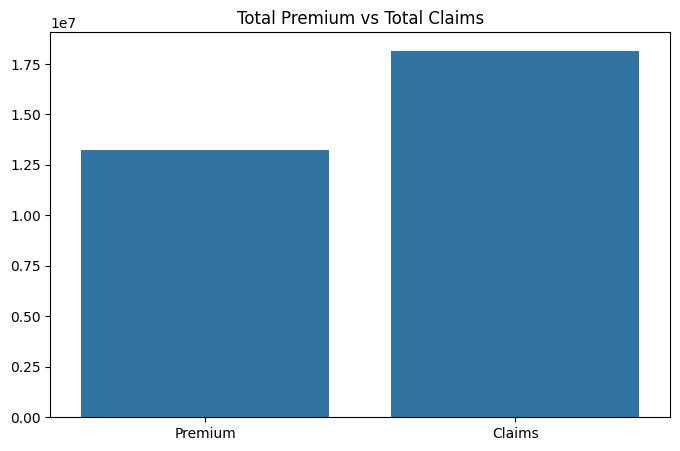

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(x=['Premium', 'Claims'], y=[total_revenue, total_claims])
plt.title("Total Premium vs Total Claims")
plt.show()

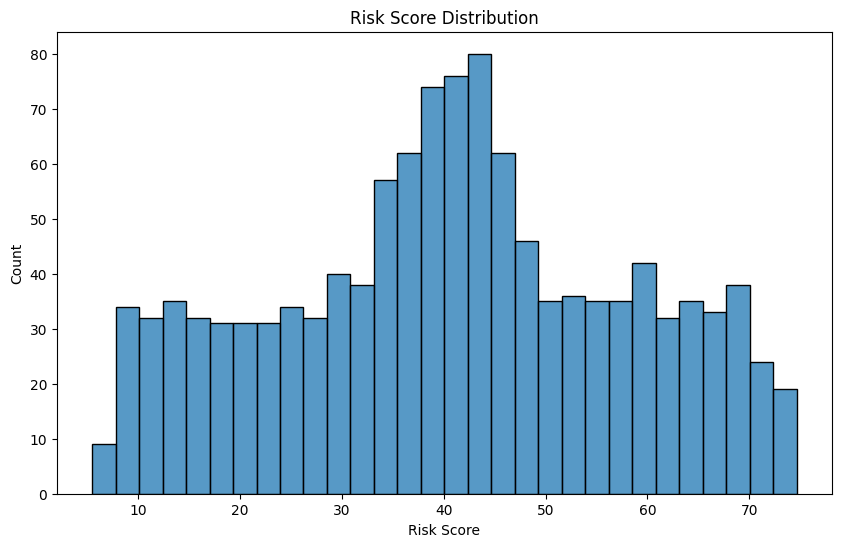

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(df['RiskScore'], bins=30)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.show()

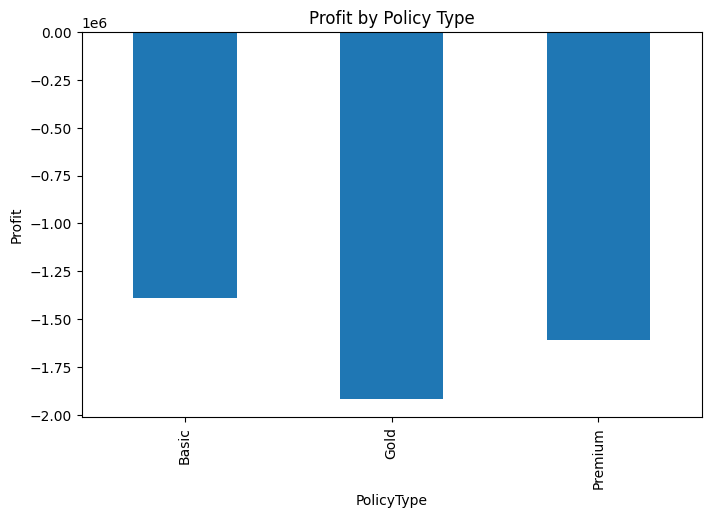

In [9]:
profit_policy = df.groupby('PolicyType')['Profit'].sum()

plt.figure(figsize=(8,5))
profit_policy.plot(kind='bar')
plt.title("Profit by Policy Type")
plt.ylabel("Profit")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select important features for segmentation
features = df[['Age', 'BMI', 'PremiumAmount', 'ClaimAmount', 'RiskScore']]

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,CustomerID,Age,Gender,BMI,SmokingStatus,ExerciseFrequency,ChronicDisease,AnnualIncome,Region,PolicyType,...,PolicyStartDate,RiskScore,Profit,AgeGroup,BMICategory,ClaimRatio,HighRiskCustomer,HighClaim,ProfitCategory,Cluster
0,10000,56,Female,32.8,Smoker,Low,Yes,147018,East,Premium,...,2023-08-03,60.84,5215,Senior,Obese,0.594037,1,0,Profit,0
1,10001,46,Female,39.3,Smoker,Low,Yes,80906,East,Gold,...,2022-03-29,58.79,4882,Senior,Obese,0.381947,1,0,Profit,0
2,10002,32,Female,20.1,Non-Smoker,High,No,30463,East,Gold,...,2021-07-25,20.03,-18160,Adult,Normal,8.079922,0,0,Loss,3
3,10003,60,Female,32.8,Smoker,Low,Yes,61973,West,Premium,...,2021-06-28,70.84,-19351,Senior,Obese,3.417364,1,1,Loss,2
4,10004,25,Male,27.8,Smoker,Medium,Yes,104694,South,Premium,...,2023-12-31,59.34,-6886,Young,Overweight,1.617246,1,0,Loss,2


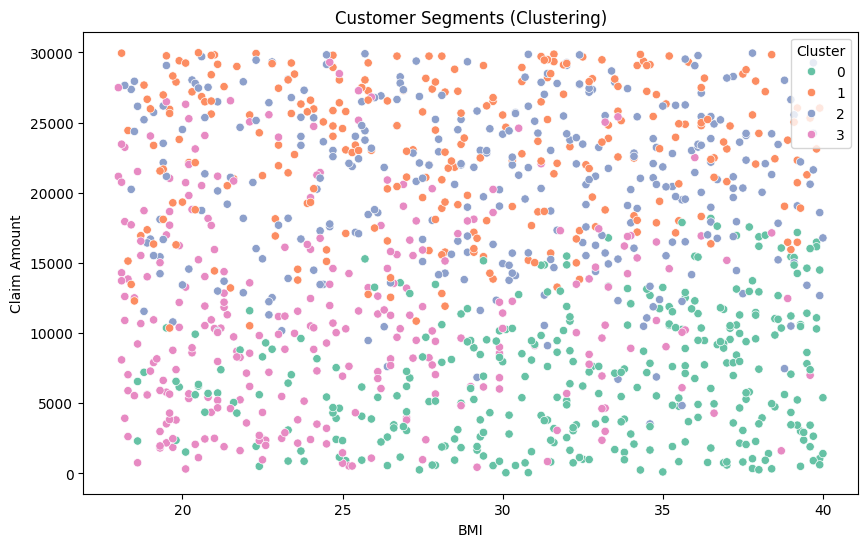

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['BMI'],
    y=df['ClaimAmount'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments (Clustering)")
plt.xlabel("BMI")
plt.ylabel("Claim Amount")
plt.show()

In [12]:
df.groupby('Cluster')[['Age','BMI','PremiumAmount','ClaimAmount','RiskScore']].mean()

,Age,BMI,PremiumAmount,ClaimAmount,RiskScore
Cluster,,,,,
0,37.161194,32.356716,12974.597015,6920.444776,47.671194
1,39.679104,28.623134,15791.988806,22980.115672,39.527239
2,41.173077,29.760577,5994.823718,20712.554487,48.505096
3,47.129825,24.738947,9811.645614,11304.828070,24.818175


In [13]:
# Extract Year & Month
df['Year'] = df['PolicyStartDate'].dt.year
df['Month'] = df['PolicyStartDate'].dt.month

# Monthly Premium Trend
monthly_premium = df.groupby(['Year','Month'])['PremiumAmount'].sum().reset_index()

# Create proper date column
monthly_premium['Date'] = pd.to_datetime(monthly_premium[['Year','Month']].assign(DAY=1))

monthly_premium.head()

,Year,Month,PremiumAmount,Date
0,2020,1,233545,2020-01-01
1,2020,2,174826,2020-02-01
2,2020,3,332875,2020-03-01
3,2020,4,334502,2020-04-01
4,2020,5,315785,2020-05-01


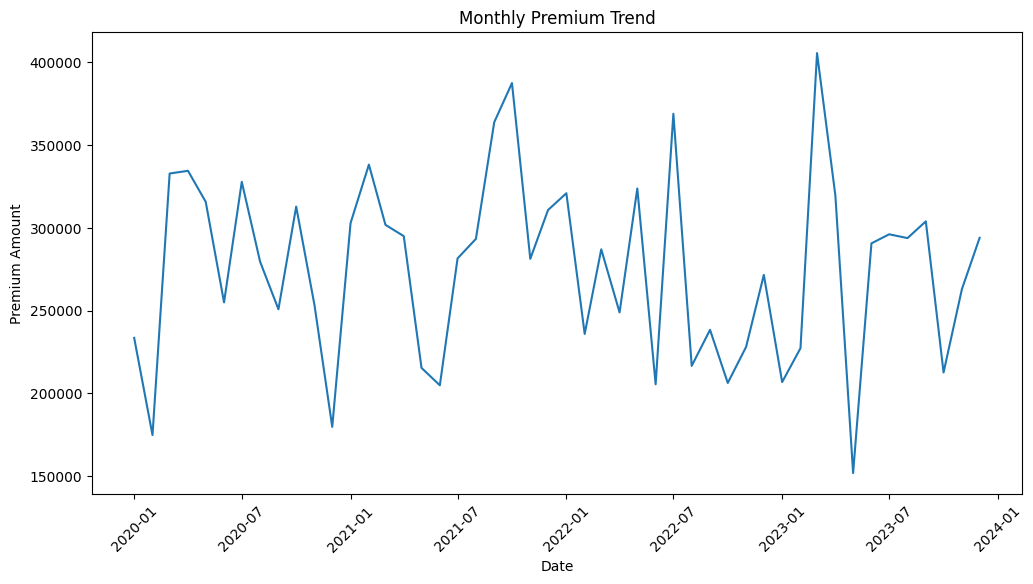

In [14]:
plt.figure(figsize=(12,6))
plt.plot(monthly_premium['Date'], monthly_premium['PremiumAmount'])

plt.title("Monthly Premium Trend")
plt.xlabel("Date")
plt.ylabel("Premium Amount")
plt.xticks(rotation=45)

plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA

# Prepare time series
ts = monthly_premium.set_index('Date')['PremiumAmount']

# Build model
model = ARIMA(ts, order=(2,1,2))
model_fit = model.fit()

# Forecast next 6 months
forecast = model_fit.forecast(steps=6)

forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,predicted_mean
2024-01-01,285888.711618
2024-02-01,262613.434440
2024-03-01,277925.243213
2024-04-01,260594.225684
2024-05-01,277413.112878
2024-06-01,260464.476340


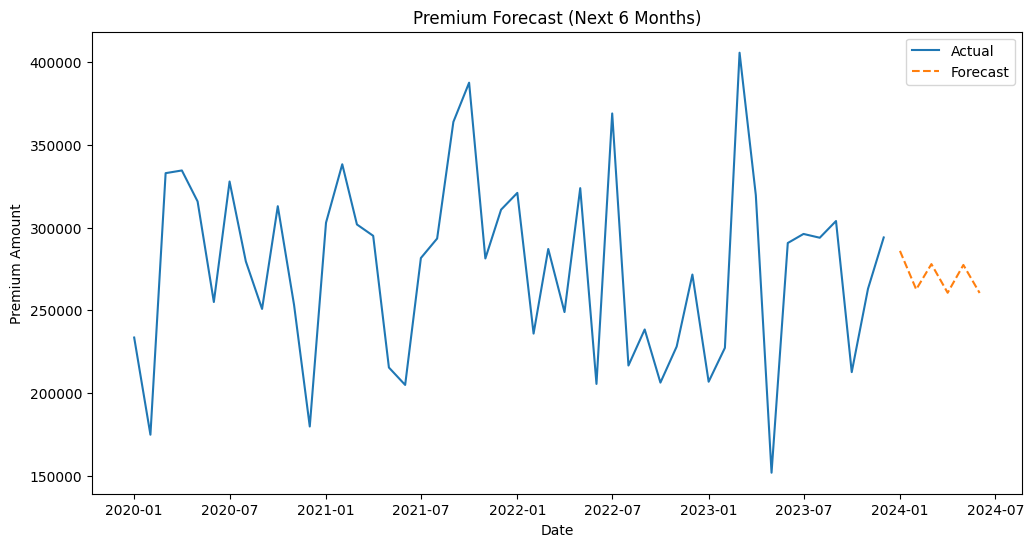

In [16]:
plt.figure(figsize=(12,6))

# Actual
plt.plot(ts, label='Actual')

# Forecast
plt.plot(forecast, label='Forecast', linestyle='dashed')

plt.title("Premium Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Premium Amount")

plt.legend()
plt.show()

In [17]:
# Save datasets
df.to_csv("health_insurance_cleaned.csv", index=False)
monthly_premium.to_csv("monthly_premium.csv", index=False)
forecast.to_csv("premium_forecast.csv")